# Esse Nootebook serve para treinar o modelo de Machine Learning com base nos dados já pré-processados


---




# >============================================================<
# Etapa 1. Instalar dependências
# >============================================================<

In [3]:
!pip install xgboost shap optuna -q

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df_encoded = pd.read_csv('/content/drive/MyDrive/Projetos/processed_data.csv')

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(X.shape, y.shape)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 9.4 MB/s eta 0:00:00
Mounted at /content/drive
(7043, 37) (7043,)


# >============================================================<
# Etapa 2. Split treino/teste (estratificado)
# >============================================================<

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantém a proporção 73/27 em ambos os conjuntos
)

print("Treino:", X_train.shape, "| Proporção churn:", y_train.mean().round(3))
print("Teste:", X_test.shape, "| Proporção churn:", y_test.mean().round(3))

Treino: (5634, 37) | Proporção churn: 0.265
Teste: (1409, 37) | Proporção churn: 0.265


# >============================================================<
# Etapa 3. Calcular Scale_pos_weight
# >============================================================<

In [5]:
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
print(f"scale_pos_weight calculado: {scale_pos_weight:.2f}")

scale_pos_weight calculado: 2.77


# >============================================================<
# Etapa 4. Treino baseline do XGboost
# >============================================================<

In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix
)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]

# >============================================================<
# Etapa 5. Avaliação das métricas Corretas
# >============================================================<



In [7]:
auc_roc = roc_auc_score(y_test, y_proba)
auc_pr = average_precision_score(y_test, y_proba)

print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR (precision-recall): {auc_pr:.4f}")

y_pred_default = (y_proba >= 0.5).astype(int)
print("\nRelatório com threshold 0.5:")
print(classification_report(y_test, y_pred_default))

AUC-ROC: 0.8395
AUC-PR (precision-recall): 0.6472

Relatório com threshold 0.5:
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.78      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



# >============================================================<
# Etapa 6. Otimização do treshold Baseado em custo do negócio
# >============================================================<

Melhor threshold (menor custo): 0.30
Custo mínimo estimado: R$ 60,000.00


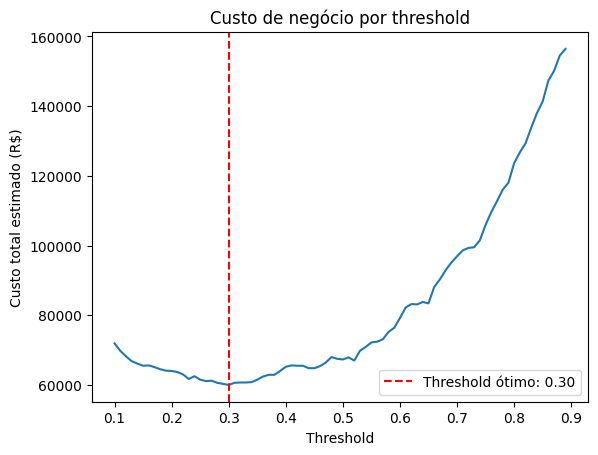

In [8]:
import numpy as np
import matplotlib.pyplot as plt

CUSTO_ADQUIRIR = 500
CUSTO_RETER = 100

thresholds = np.arange(0.1, 0.9, 0.01)
costs = []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    custo_total = (fn * CUSTO_ADQUIRIR) + (fp * CUSTO_RETER)
    costs.append(custo_total)

best_threshold = thresholds[np.argmin(costs)]
print(f"Melhor threshold (menor custo): {best_threshold:.2f}")
print(f"Custo mínimo estimado: R$ {min(costs):,.2f}")

plt.plot(thresholds, costs)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Threshold ótimo: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Custo total estimado (R$)')
plt.title('Custo de negócio por threshold')
plt.legend()
plt.show()

# >============================================================<
# Etapa 7. Avaliação Final com o treshold Otimizado
# >============================================================<



In [9]:
y_pred_final = (y_proba >= best_threshold).astype(int)

print(f"Relatório com threshold otimizado ({best_threshold:.2f}):")
print(classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
print("Matriz de confusão:\n", cm)

Relatório com threshold otimizado (0.30):
              precision    recall  f1-score   support

           0       0.94      0.60      0.74      1035
           1       0.45      0.90      0.60       374

    accuracy                           0.68      1409
   macro avg       0.70      0.75      0.67      1409
weighted avg       0.81      0.68      0.70      1409

Matriz de confusão:
 [[625 410]
 [ 38 336]]


# >============================================================<
# Etapa 8. Otimização de hiperparâmetros com Optuna
# >============================================================<

In [10]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric': 'aucpr',
        'random_state': 42,
        'n_jobs': -1
    }

    clf = XGBClassifier(**params)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='average_precision')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Melhores parâmetros:", study.best_params)
print("Melhor AUC-PR (CV):", study.best_value)

[I 2026-07-24 15:35:25,250] A new study created in memory with name: no-name-b9d95464-b4cd-462e-b36b-98fb5d668b67


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-07-24 15:35:38,107] Trial 0 finished with value: 0.6244477689962485 and parameters: {'n_estimators': 130, 'max_depth': 6, 'learning_rate': 0.19573816118449647, 'subsample': 0.9927512149658602, 'colsample_bytree': 0.959764012581762}. Best is trial 0 with value: 0.6244477689962485.
[I 2026-07-24 15:35:55,467] Trial 1 finished with value: 0.6574995312934021 and parameters: {'n_estimators': 174, 'max_depth': 4, 'learning_rate': 0.08936687827211595, 'subsample': 0.8613435155056739, 'colsample_bytree': 0.9763695545836334}. Best is trial 1 with value: 0.6574995312934021.
[I 2026-07-24 15:36:12,350] Trial 2 finished with value: 0.6286526190870048 and parameters: {'n_estimators': 422, 'max_depth': 7, 'learning_rate': 0.04481160667224026, 'subsample': 0.8019693804696779, 'colsample_bytree': 0.887532737937637}. Best is trial 1 with value: 0.6574995312934021.
[I 2026-07-24 15:36:14,736] Trial 3 finished with value: 0.6552840060259248 and parameters: {'n_estimators': 298, 'max_depth': 6, 'l

# >============================================================<
# Etapa 9-Treinar modelo final com os melhores parâmetros
# >============================================================<

In [11]:
best_params = study.best_params
best_params.update({
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'aucpr',
    'random_state': 42,
    'n_jobs': -1
})

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train)

y_proba_final = final_model.predict_proba(X_test)[:, 1]
print("AUC-PR final:", average_precision_score(y_test, y_proba_final))
print("AUC-ROC final:", roc_auc_score(y_test, y_proba_final))

AUC-PR final: 0.661333651004429
AUC-ROC final: 0.8466235242450075


# >============================================================<
# Etapa 10-SHAP: importância geral das features
# >============================================================<

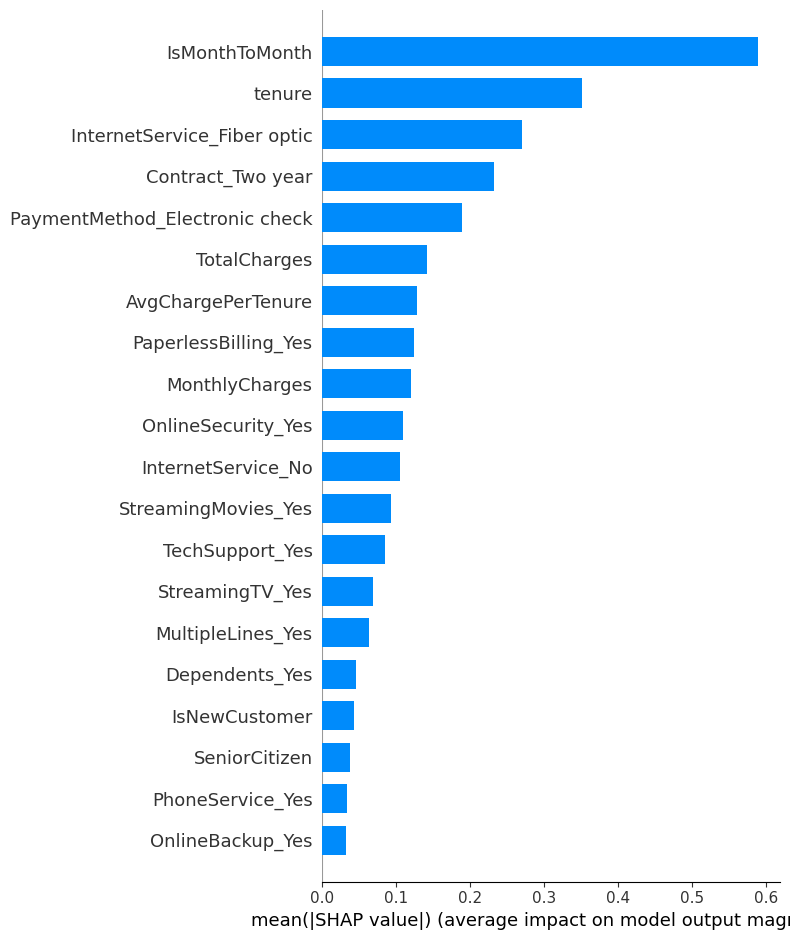

In [12]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar')

# >============================================================<
# Etapa 12 — SHAP: explicação individual de um cliente
# >============================================================<

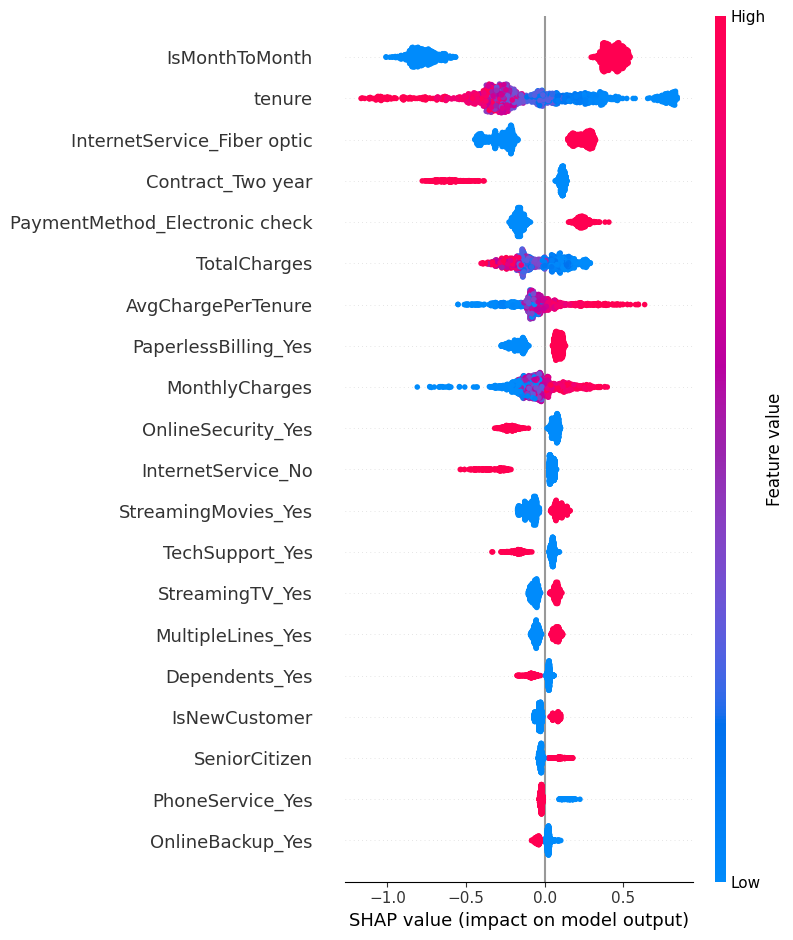

In [13]:
shap.summary_plot(shap_values, X_test)

# >============================================================<
# Etapa 13 — Função de top motivos (reaproveitável na API)
# >============================================================<


In [14]:

def top_reasons(idx, n=3):
    shap_row = shap_values[idx]
    feature_names = X_test.columns
    contrib = pd.Series(shap_row, index=feature_names).sort_values(key=abs, ascending=False)
    return contrib.head(n)

idx = 0

print(top_reasons(idx))

tenure              -1.016663
IsMonthToMonth      -0.822212
Contract_Two year   -0.655010
dtype: float32


# >============================================================<
# Etapa 14 — Salvar tudo
# >============================================================<

In [17]:
import joblib

# formato nativo do XGBoost (mais portável entre versões/ambientes)
final_model.save_model('/content/drive/MyDrive/Projetos/xgb_churn_model.json')

# mantém os outros dois como estavam
joblib.dump(list(X.columns), '/content/drive/MyDrive/Projetos/model_columns.pkl')
joblib.dump(best_threshold, '/content/drive/MyDrive/Projetos/best_threshold.pkl')

print("Modelo (JSON), colunas e threshold salvos com sucesso!")

Modelo (JSON), colunas e threshold salvos com sucesso!
